# Figures for the paper

Generates the two figures used in the Results section of the poster and report

## 1. Imports

In [2]:
# If running on Colab or a fresh env, uncomment the next line:
# !pip install -q SciencePlots

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

import scienceplots
plt.style.use(['science', 'no-latex', 'grid'])

%matplotlib inline

# Override defaults for paper-figure legibility
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 8.5,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.frameon': False,
    'lines.linewidth': 1.4,
    'lines.markersize': 5.5,
})

# Colorblind-friendly palette (Wong 2011) — one color per toxicity class
C_E = '#D55E00'    # Explicit — vermilion
C_I = '#CC79A7'    # Implicit — magenta (hypothesis class — distinctive)
C_A = '#009E73'    # Action   — bluish green
C_O = '#0072B2'    # Other    — blue
C_MACRO = 'black'  # Macro-F1

C_UNW = '#56B4E9'  # sky-blue
C_W   = '#E69F00'  # orange

## 2. Data

All numbers come from the final-eval cells of the respective notebooks. If you rerun a notebook and get new numbers, just edit the entry here.

In [3]:
# Context-window ablation (unweighted CE)
ks       = [0, 1, 3, 5, 10]
macro_f1 = [0.8200, 0.8401, 0.8398, 0.8260, 0.8327]
f1_E     = [0.8193, 0.8496, 0.8457, 0.8342, 0.8443]
f1_I     = [0.7350, 0.7619, 0.7555, 0.7355, 0.7457]
f1_A     = [0.7781, 0.7965, 0.8073, 0.7853, 0.7905]
f1_O     = [0.9477, 0.9522, 0.9508, 0.9491, 0.9504]

# Per-class precision/recall on the Implicit class
precision_I = [0.9245, 0.8770, 0.9062, 0.8392, 0.9086]
recall_I    = [0.6100, 0.6735, 0.6478, 0.6546, 0.6323]

# Weighted vs unweighted control at k = 0
classes    = ['E', 'I', 'A', 'O', 'Macro']
unweighted = [0.8193, 0.7350, 0.7781, 0.9477, 0.8200]
weighted   = [0.8391, 0.7431, 0.7737, 0.9477, 0.8259]

## 3. Figure 1: F1 across context sizes

Per-class and macro F1 as a function of the context window size *k*. Categorical x-axis, baseline reference, peak highlighted with a star.

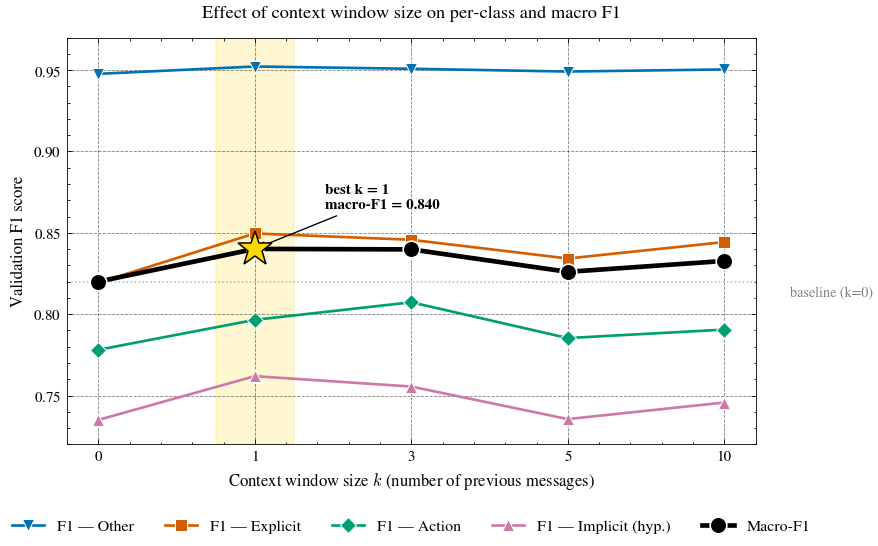

In [4]:
x_pos = np.arange(len(ks))   # 0, 1, 2, 3, 4 — categorical positions
x_labels = [str(k) for k in ks]

fig, ax = plt.subplots(figsize=(7.5, 4.8))

best_idx = int(np.argmax(macro_f1))
ax.axvspan(best_idx - 0.25, best_idx + 0.25, color='gold', alpha=0.18, zorder=0)

ax.axhline(macro_f1[0], color='gray', linewidth=0.9, linestyle=':', alpha=0.6, zorder=1)
ax.text(len(ks) - 0.05, macro_f1[0] - 0.003, 'baseline (k=0)',
        fontsize=8.5, color='gray', ha='right', va='top')

ax.plot(x_pos, f1_O, 'v-', linewidth=1.6, markersize=7, color=C_O,
        markeredgecolor='white', markeredgewidth=0.6, label='F1 — Other')
ax.plot(x_pos, f1_E, 's-', linewidth=1.6, markersize=7, color=C_E,
        markeredgecolor='white', markeredgewidth=0.6, label='F1 — Explicit')
ax.plot(x_pos, f1_A, 'D-', linewidth=1.6, markersize=7, color=C_A,
        markeredgecolor='white', markeredgewidth=0.6, label='F1 — Action')
ax.plot(x_pos, f1_I, '^-', linewidth=1.6, markersize=7, color=C_I,
        markeredgecolor='white', markeredgewidth=0.6, label='F1 — Implicit (hyp.)')

ax.plot(x_pos, macro_f1, 'o-', linewidth=2.8, markersize=10, color=C_MACRO,
        markeredgecolor='white', markeredgewidth=1.0, label='Macro-F1', zorder=5)

ax.plot(best_idx, macro_f1[best_idx], marker='*', markersize=22,
        color='gold', markeredgecolor='black', markeredgewidth=0.9, zorder=6)
ax.annotate(f'best k = {ks[best_idx]}\nmacro-F1 = {macro_f1[best_idx]:.3f}',
            xy=(best_idx, macro_f1[best_idx]),
            xytext=(best_idx + 0.45, macro_f1[best_idx] + 0.025),
            fontsize=9, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='black', lw=0.8))

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_xlabel('Context window size $k$ (number of previous messages)')
ax.set_ylabel('Validation F1 score')
ax.set_title('Effect of context window size on per-class and macro F1', pad=12)
ax.set_ylim(0.72, 0.97)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.05))
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5, fontsize=9.5)

plt.tight_layout()
plt.savefig('fig1_f1_vs_k.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Figure 2: Word clouds per toxicity class

For each of the four classes (E, I, A, O), generate a word cloud from the training-set utterances. Gives the poster reader an immediate, qualitative sense of what each class actually looks like in DOTA2 chat.

> Requires `wordcloud`. Install with `pip install wordcloud`. Also needs `CONDA_train.csv`; the cell looks for it at `../CONDA/data/CONDA_train.csv` (the standard location in this project) or in the current directory as fallback.

Loading ..\CONDA\data\CONDA_train.csv
Train rows after cleaning: 26914


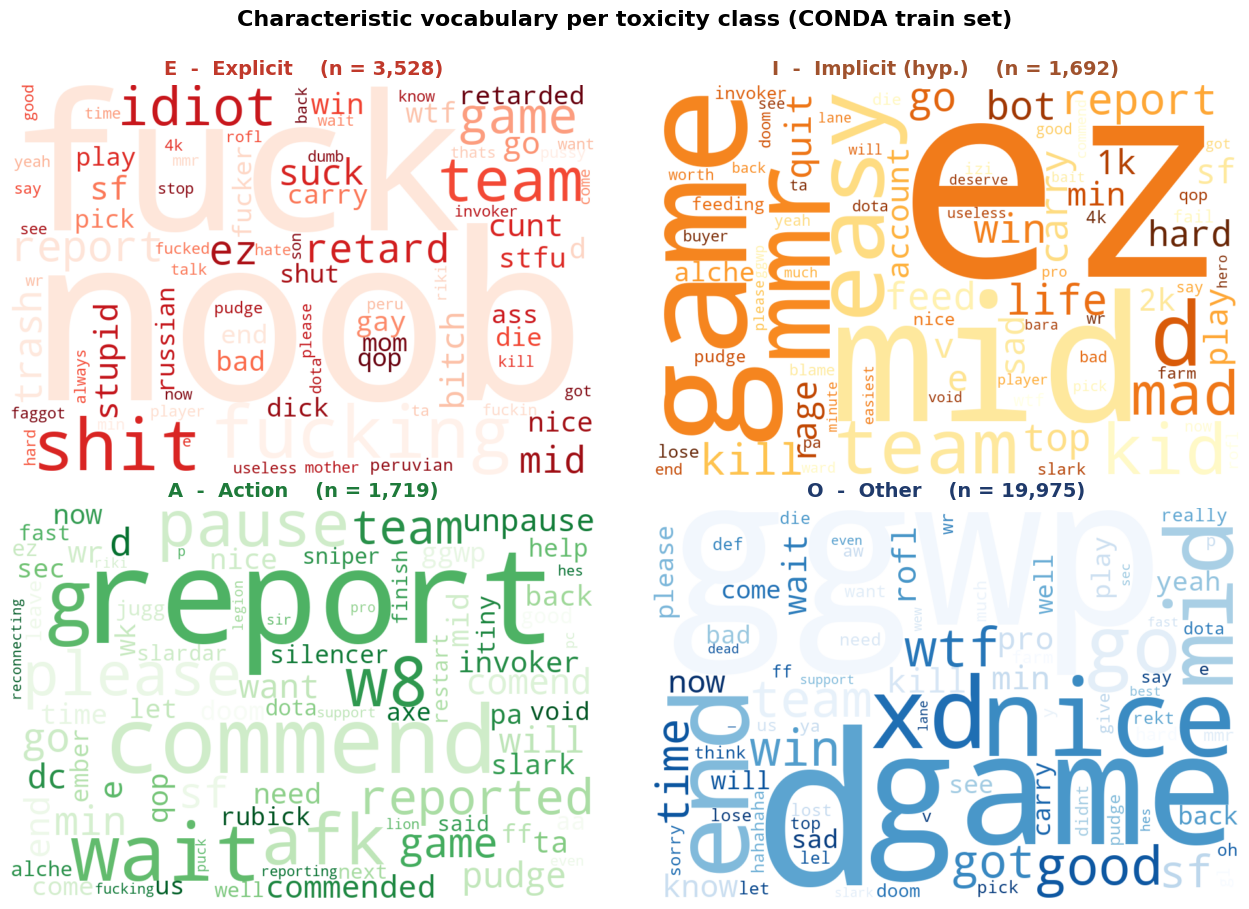

In [19]:
# --- Figure 13: Word clouds per toxicity class ---
import os
from pathlib import Path as _P
import pandas as pd
from wordcloud import WordCloud, STOPWORDS

CANDIDATE_PATHS = [
    _P('../CONDA/data/CONDA_train.csv'),
    _P('CONDA_train.csv'),
]
csv_path = next((p for p in CANDIDATE_PATHS if p.exists()), None)
assert csv_path is not None, "CONDA_train.csv not found."
print(f'Loading {csv_path}')
df_wc = pd.read_csv(csv_path)
df_wc = df_wc.dropna(subset=['utterance', 'intentClass']).copy()

# Remove the [SEPA] separator token that CONDA uses inside utterances
df_wc['utterance'] = (df_wc['utterance'].astype(str)
                                       .str.replace(r'\[?SEPA\]?', ' ', regex=True))

print(f'Train rows after cleaning: {len(df_wc)}')

EXTRA_STOPS = {
    'sepa', 'sepb',  # CONDA-specific separator tokens
    'lol', 'lmao', 'pls', 'plz', 'omg', 'wow', 'haha', 'hahaha',
    'gg', 'wp', 'hi', 'hey', 'yo', 'thx', 'ty', 'thanks',
    'yes', 'no', 'ok', 'okay', 'nope', 'yep', 'rly', 'sure',
    'man', 'bro', 'dude', 'guys', 'people',
    'one', 'two', 'three', 'lot', 'still', 'first',
    'u', 'ur',
    'dont', 'wont', 'cant', 'im',
}
stops = set(STOPWORDS) | EXTRA_STOPS

class_cfg = {
    'E': {'name': 'Explicit',        'color': '#c0392b', 'cmap': 'Reds'},
    'I': {'name': 'Implicit (hyp.)', 'color': '#a0522d', 'cmap': 'YlOrBr'},
    'A': {'name': 'Action',          'color': '#1e7a3a', 'cmap': 'Greens'},
    'O': {'name': 'Other',           'color': '#1f3a6b', 'cmap': 'Blues'},
}

with plt.style.context('default'):
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    for ax, (cls, cfg) in zip(axes.flat, class_cfg.items()):
        texts = df_wc.loc[df_wc['intentClass'] == cls, 'utterance'].astype(str).tolist()
        texts = [t for t in texts if t and t.lower() != 'nan']
        joined = ' '.join(texts).lower()
        if not joined.strip():
            ax.text(0.5, 0.5, f'(no data for class {cls})',
                    ha='center', va='center', fontsize=14)
            ax.axis('off')
            continue

        wc = WordCloud(width=900, height=600,
                       background_color='white',
                       colormap=cfg['cmap'],
                       stopwords=stops,
                       collocations=False,
                       prefer_horizontal=0.9,
                       max_words=80,
                       min_font_size=10,
                       relative_scaling=0.45,
                       random_state=42).generate(joined)
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f'{cls}  -  {cfg["name"]}    (n = {len(texts):,})',
                     fontsize=14, fontweight='bold', color=cfg['color'],
                     pad=8)
        ax.axis('off')

    fig.suptitle('Characteristic vocabulary per toxicity class (CONDA train set)',
                 fontsize=16, fontweight='bold', y=1.005)

    plt.tight_layout()
    plt.savefig('fig13_wordclouds.png', dpi=300, bbox_inches='tight',
                facecolor='white')
    plt.show()
